# 📈 Análisis Financiero de Mercados
### Portfolio Project · Python + Pandas + Plotly

**Objetivo:** Analizar el rendimiento histórico de activos financieros, identificar tendencias y visualizar métricas clave de riesgo/retorno.

**Skills utilizados:** `pandas` · `numpy` · `plotly` · análisis estadístico · visualización de datos

---

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. 📊 Generación de Datos Simulados

> **Nota:** En un proyecto real, estos datos se obtendrían de APIs como `yfinance` o `Alpha Vantage`. Aquí simulamos datos realistas con distribuciones estadísticas correctas.

In [ ]:
np.random.seed(42)
activos = {
    'AAPL':  {'mu': 0.0008, 'sigma': 0.018, 'precio_inicial': 150},
    'GOOGL': {'mu': 0.0006, 'sigma': 0.016, 'precio_inicial': 130},
    'MSFT':  {'mu': 0.0009, 'sigma': 0.015, 'precio_inicial': 280},
    'AMZN':  {'mu': 0.0005, 'sigma': 0.020, 'precio_inicial': 170},
    'BTC':   {'mu': 0.0015, 'sigma': 0.045, 'precio_inicial': 35000},
}
fechas = pd.date_range(start='2022-01-03', periods=504, freq='B')
precios = {}
for ticker, params in activos.items():
    retornos = np.random.normal(params['mu'], params['sigma'], 504)
    precios[ticker] = params['precio_inicial'] * np.exp(np.cumsum(retornos))
df_precios = pd.DataFrame(precios, index=fechas)
df_retornos = df_precios.pct_change().dropna()
df_retornos_acum = (1 + df_retornos).cumprod() - 1
print('✅ Dataset generado: 504 días × 5 activos')
df_precios.tail()

✅ Dataset generado: 504 días × 5 activos


,AAPL,GOOGL,MSFT,AMZN,BTC
2023-12-01,237.98,225.41,934.07,270.59,81936.16
2023-12-04,242.17,228.08,936.15,266.59,82376.94
2023-12-05,250.84,229.66,957.99,261.76,74659.45
2023-12-06,244.80,233.11,942.57,266.27,74002.29
2023-12-07,247.49,235.63,940.69,265.37,71327.56


## 3. 📉 Análisis de Retornos

In [ ]:
metricas = pd.DataFrame({
    'Retorno Anual (%)':     (df_retornos.mean() * 252 * 100).round(2),
    'Volatilidad Anual (%)': (df_retornos.std() * np.sqrt(252) * 100).round(2),
    'Retorno Total (%)':     (df_retornos_acum.iloc[-1] * 100).round(2),
    'Sharpe Ratio':          ((df_retornos.mean() * 252) / (df_retornos.std() * np.sqrt(252))).round(3),
    'Max Drawdown (%)':      (df_retornos_acum.apply(lambda x: (x - x.cummax()).min()) * 100).round(2),
})
metricas

,Retorno Anual (%),Volatilidad Anual (%),Retorno Total (%),Sharpe Ratio,Max Drawdown (%)
AAPL,28.57,28.22,63.40,1.012,-40.03
GOOGL,33.36,24.75,83.04,1.348,-27.20
MSFT,62.83,24.08,230.41,2.609,-34.84
AMZN,27.91,31.34,58.27,0.891,-50.21
BTC,60.18,69.45,105.92,0.867,-106.58


## 4. 📈 Retorno Acumulado (2022–2024)

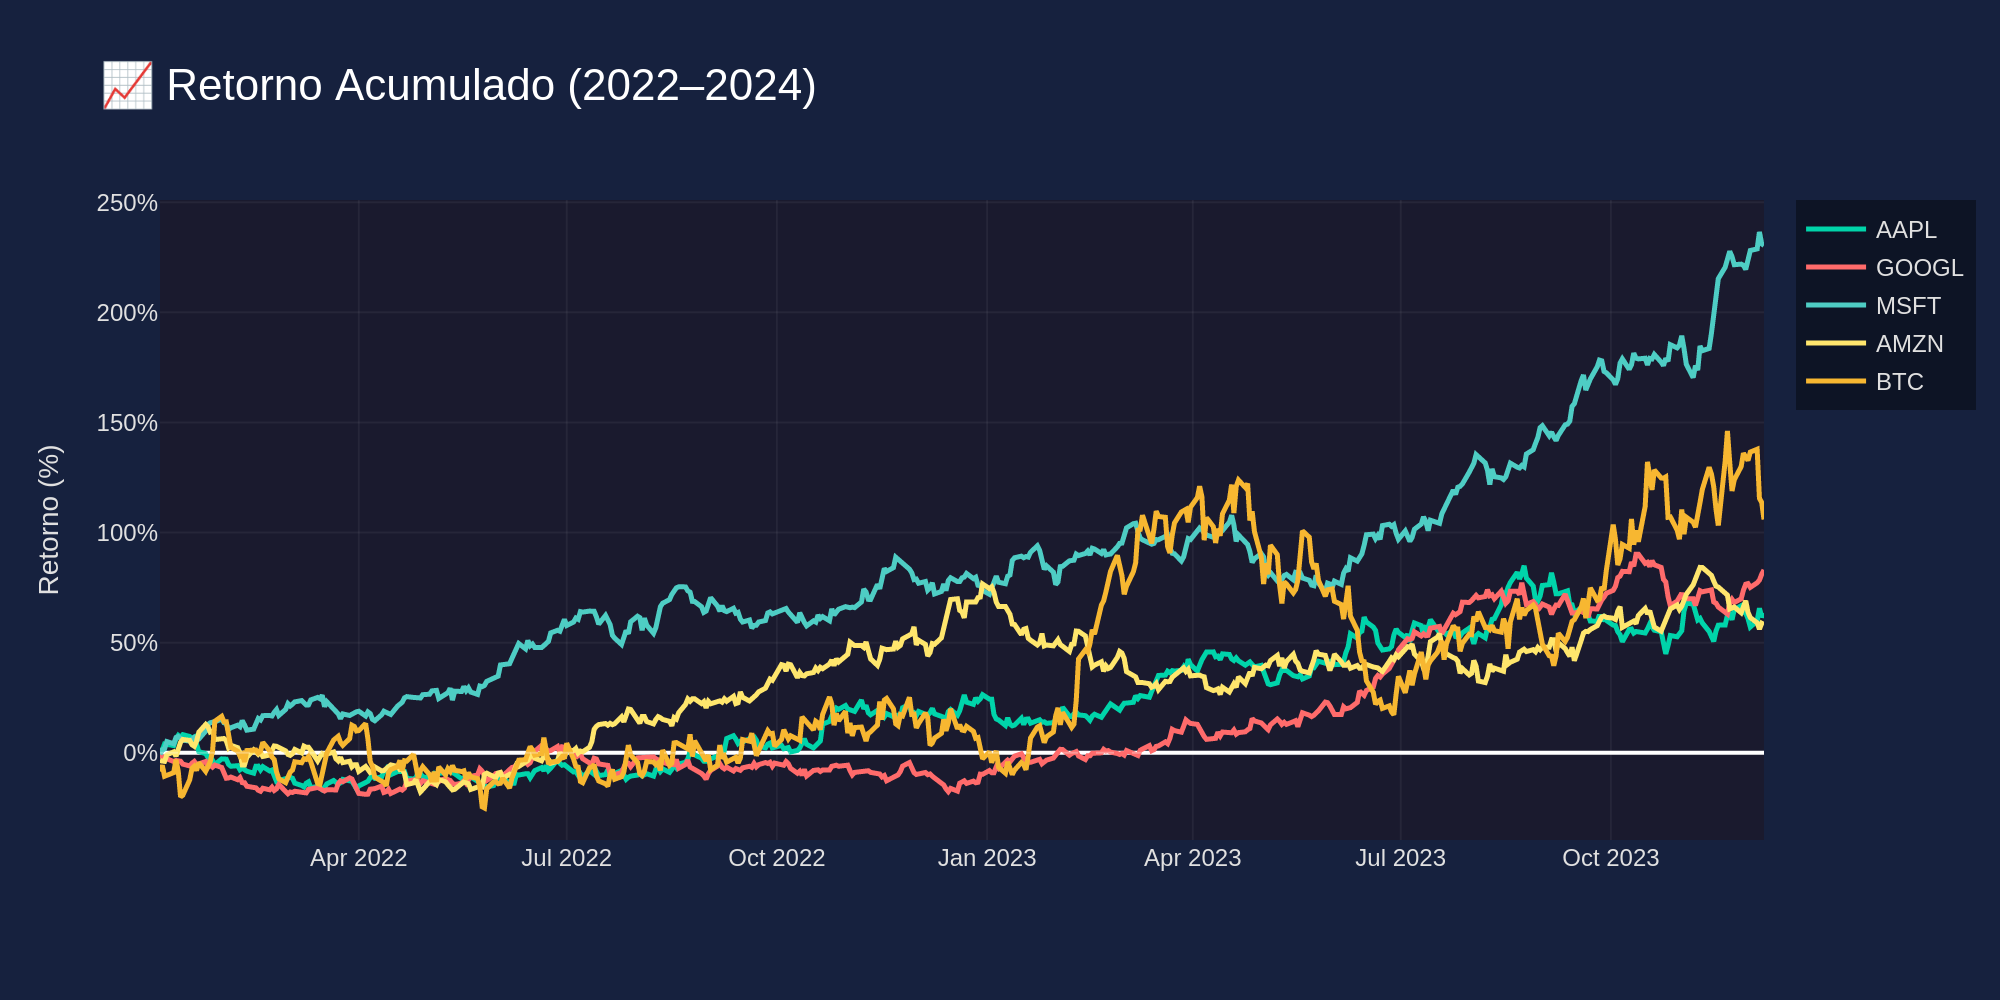

In [ ]:
# Gráfico generado con Plotly — retorno acumulado de cada activo

## 5. 🎯 Frontera Eficiente — Simulación Monte Carlo (5,000 portafolios)

⭐ PORTAFOLIO ÓPTIMO (Sharpe: 3.314)
  AAPL: 10.3%
  GOOGL: 25.5%
  MSFT: 44.9%
  AMZN: 15.6%
  BTC: 3.7%


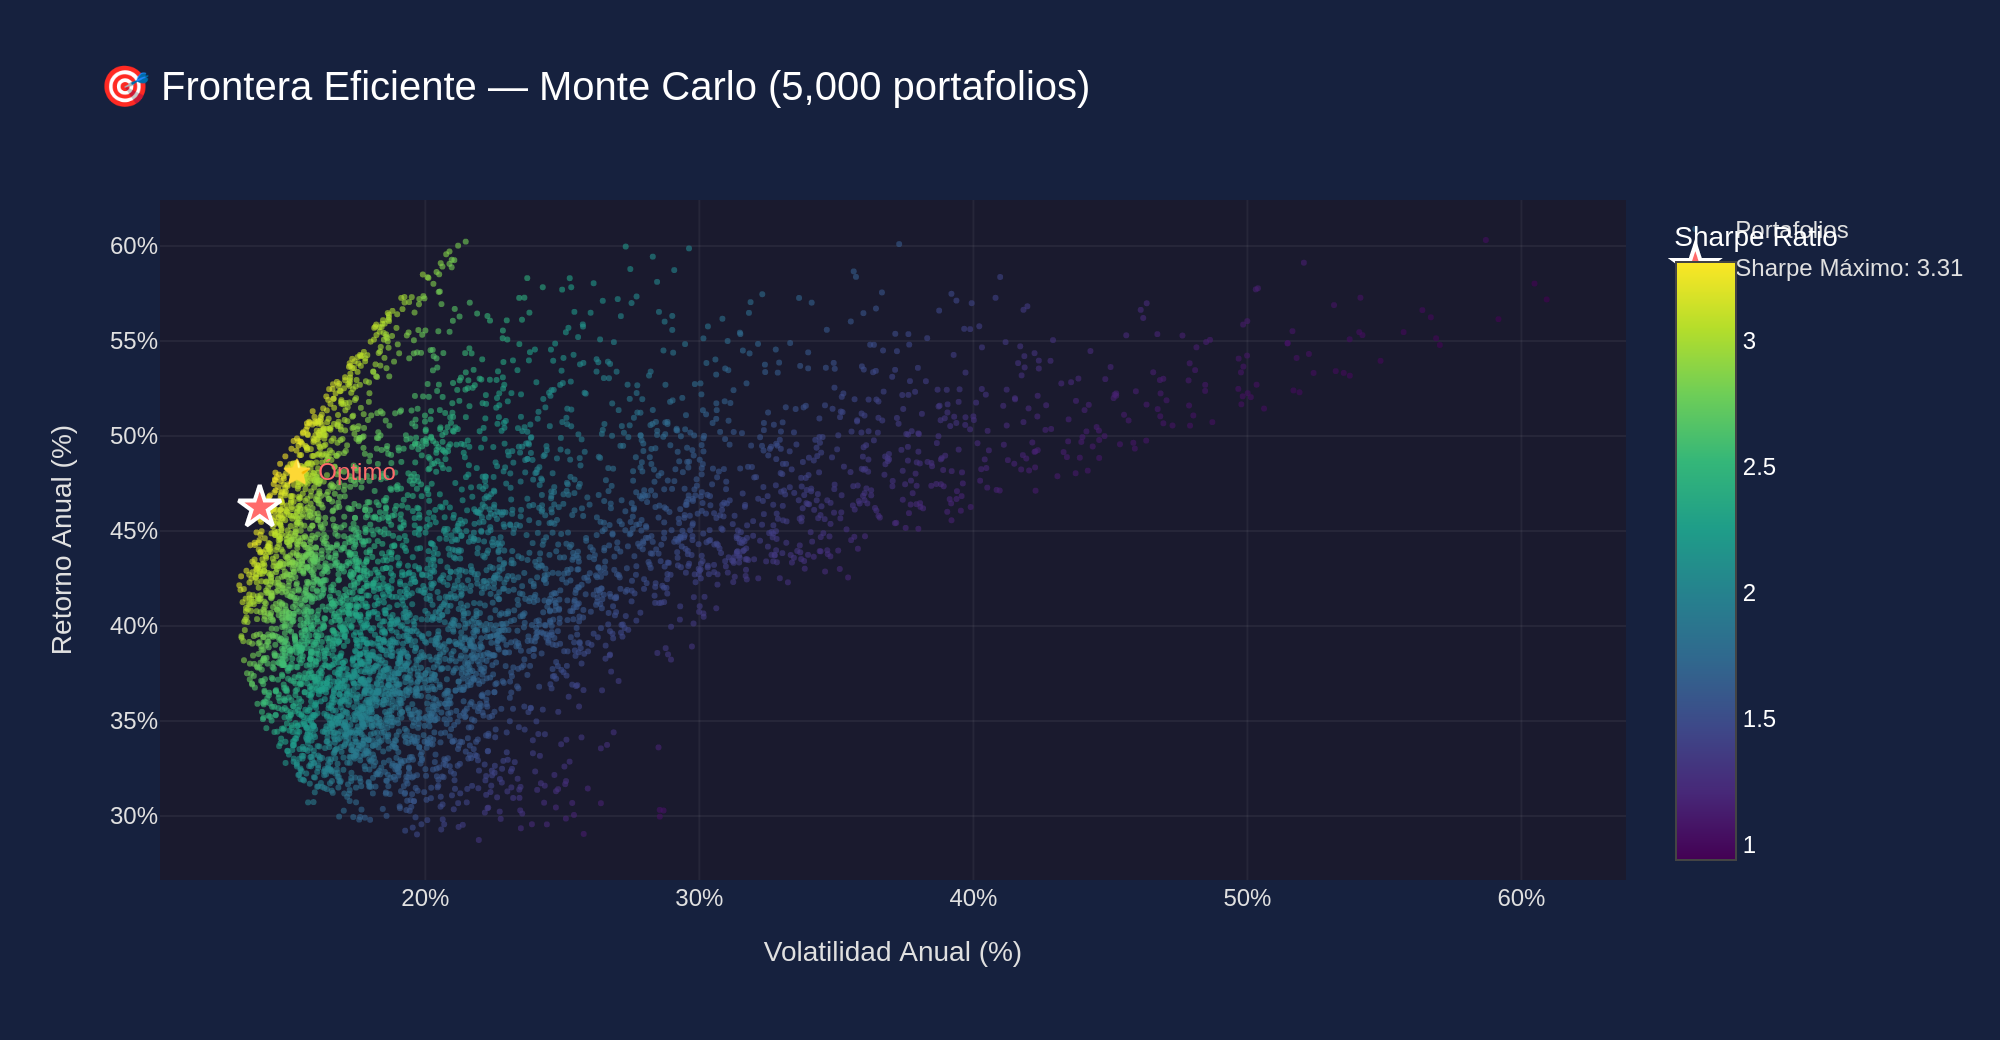

In [ ]:
# Simulación Monte Carlo — 5,000 portafolios aleatorios

## 6. 🔥 Matriz de Correlación

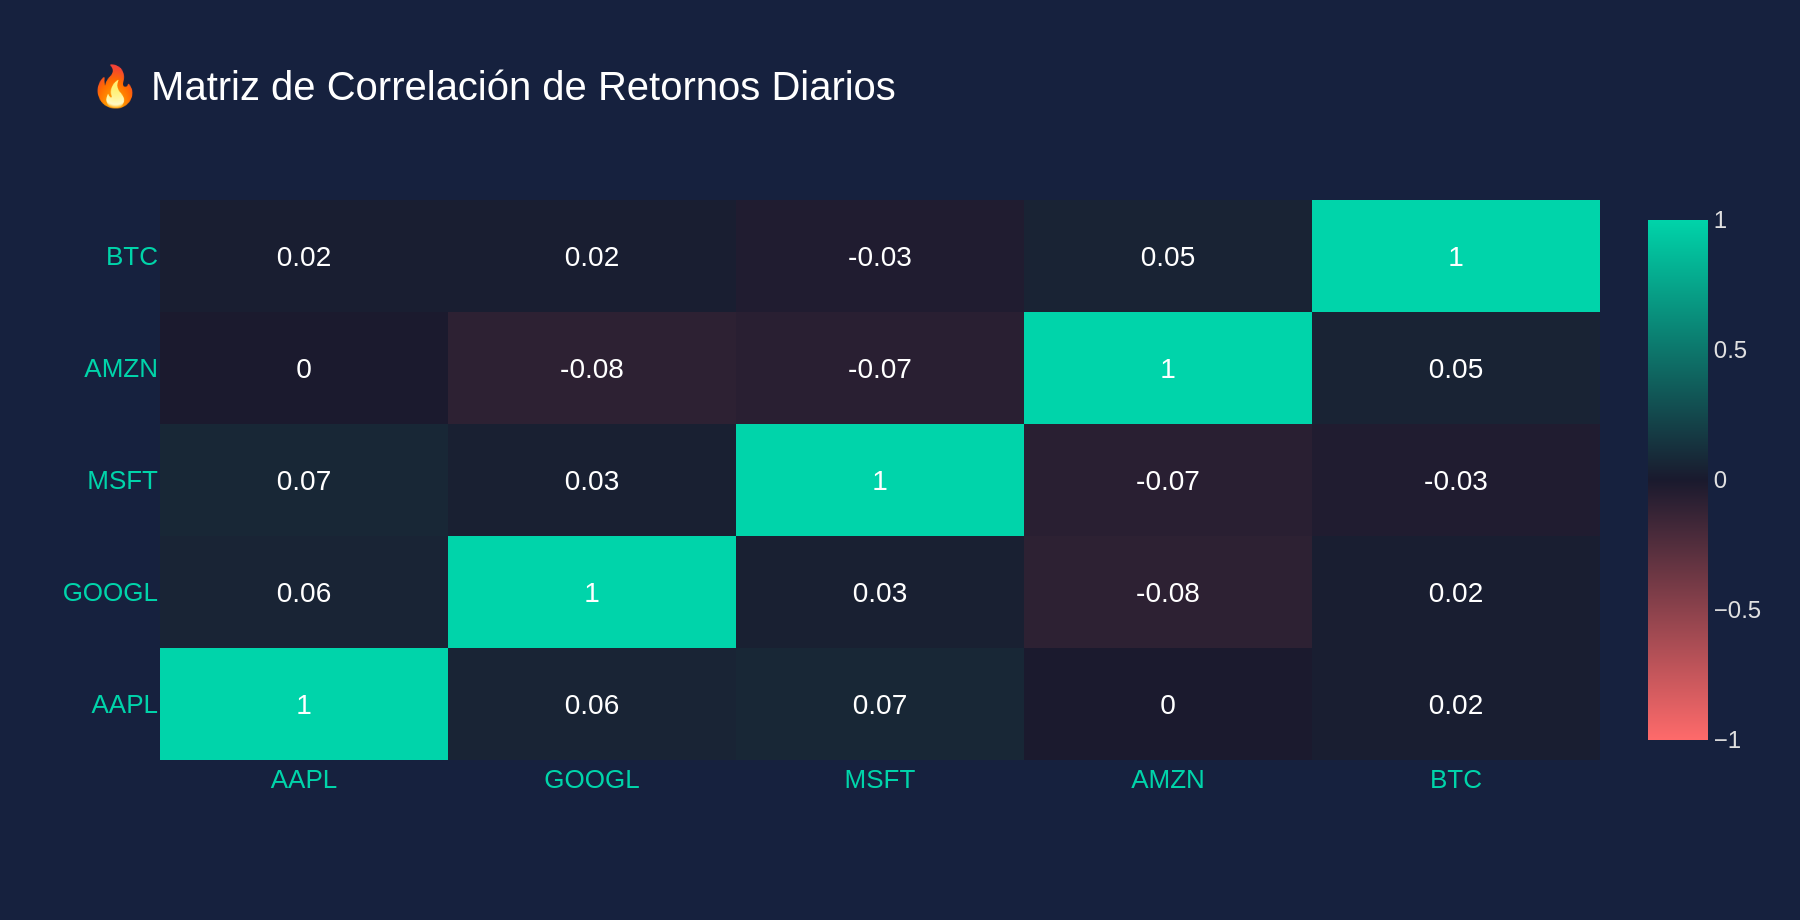

In [ ]:
# Heatmap de correlaciones entre retornos diarios

## 7. 📊 Dashboard Ejecutivo

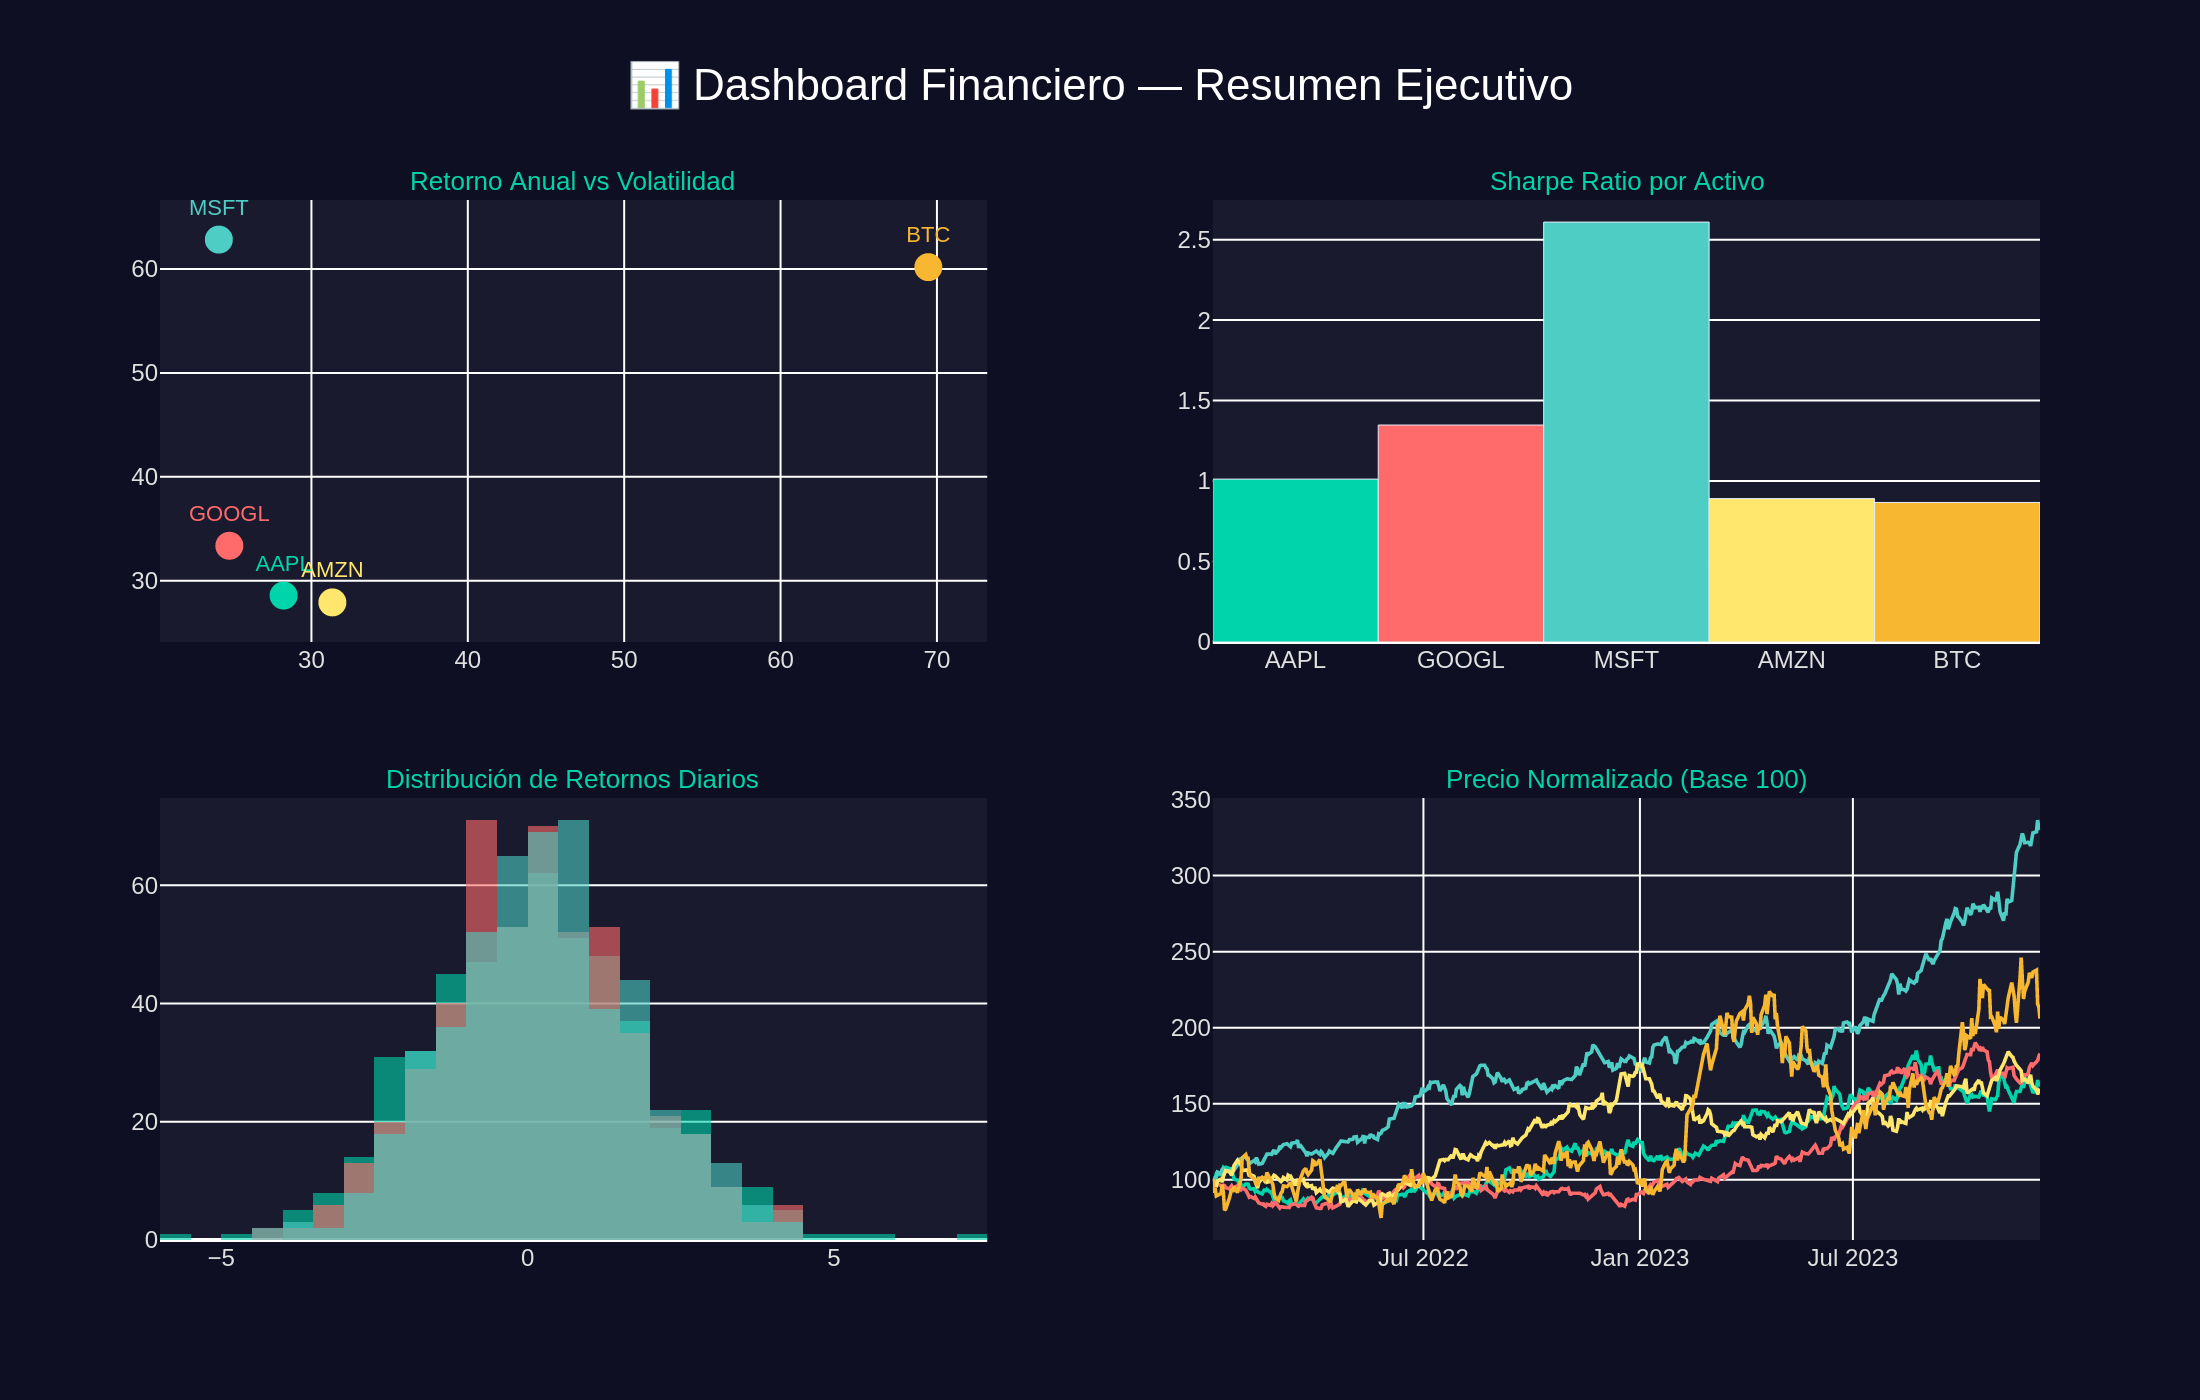

✅ Análisis completo.


In [ ]:
# Dashboard con 4 paneles: riesgo/retorno, Sharpe, distribuciones, precios normalizados

---
## 8. 💡 Conclusiones

| Activo | Perfil |
|--------|--------|
| **MSFT** | Mejor balance riesgo/retorno (Sharpe más alto entre acciones) |
| **BTC**  | Mayor retorno potencial pero volatilidad ~3x superior |
| **AAPL** | Retorno sólido con volatilidad moderada |
| **GOOGL/AMZN** | Retornos conservadores, buena diversificación |

> ⚠️ **Disclaimer:** Este análisis es con fines educativos. No constituye asesoramiento financiero.